# Part D — λ Ablation Study: MI Penalty Strength vs. Performance
## MITR-InfoNCE on BoolQ (DistilBERT)

### Experiment
This notebook implements the λ ablation experiment proposed in Part C.
It investigates how mutual information penalty strength (λ) affects
validation accuracy, logical contradiction rate, and inter-layer CKA
similarity when fine-tuning DistilBERT on BoolQ with InfoNCE-based
MITR regularization.

### Hypothesis
If we vary λ across {0, 0.001, 0.01, 0.1, 0.5}, then accuracy will
improve up to an optimal λ and then degrade, because moderate MI
reduction removes layer redundancy while excessive regularization
destroys useful shared information across layers.

### Setup
| Parameter       | Value                                      |
|-----------------|--------------------------------------------|
| Model           | distilbert-base-uncased                    |
| Dataset         | BoolQ                                      |
| MI Strategy     | InfoNCE (best performer in original study) |
| λ values        | {0, 0.001, 0.01, 0.1, 0.5}                |
| Epochs          | 3                                          |
| Train samples   | 4,000                                      |
| Val samples     | 1,000                                      |
| Metrics         | Val accuracy, contradiction rate, mean CKA |

### Note
This experiment is scoped down to fit Colab T4 memory and time limits.
The full experiment would use the complete BoolQ split (8,000 train /
1,500 val) for 5 epochs with 3 random seeds and error bars on all
reported metrics. Results here are single-seed and should be treated
as indicative rather than statistically conclusive.



In [2]:
# Run once - installs / upgrades required packages
!pip install -q --upgrade "transformers>=4.36" datasets accelerate matplotlib seaborn tqdm
print("Done.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 77.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 36.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 72.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 16.8 MB/s eta 0:00:00
Done.


In [3]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from transformers import DistilBertTokenizerFast, DistilBertModel
from datasets import load_dataset
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.metrics import accuracy_score

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


## 1. Load and Prepare BoolQ

In [4]:
raw = load_dataset('boolq')
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

MAX_LEN = 256
TRAIN_SIZE = 4000
VAL_SIZE = 1000

def tokenize_fn(example):
    enc = tokenizer(
        example['question'],
        example['passage'],
        truncation=True,
        max_length=MAX_LEN,
        padding='max_length'
    )
    enc['label'] = int(example['answer'])
    return enc

train_ds = raw['train'].select(range(TRAIN_SIZE)).map(tokenize_fn, batched=False)
val_ds   = raw['validation'].select(range(VAL_SIZE)).map(tokenize_fn, batched=False)

train_ds.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
val_ds.set_format(type='torch',   columns=['input_ids', 'attention_mask', 'label'])

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=2)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.69M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/1.26M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/9427 [00:00<?, ? examples/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Train: 4000 | Val: 1000


## 2. Model Definition

We hook all 6 DistilBERT hidden layers and compute:
- **InfoNCE MI penalty** between each consecutive layer pair
- **CKA similarity** between consecutive layers (for tracking representation collapse)

In [5]:
# ── InfoNCE estimator (learnable projection head) ──────────────────────────
class InfoNCEHead(nn.Module):
    def __init__(self, hidden_dim=768, proj_dim=128, temperature=0.07):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(hidden_dim, proj_dim),
            nn.ReLU(),
            nn.Linear(proj_dim, proj_dim)
        )
        self.temp = temperature

    def forward(self, h_i, h_j):
        # h_i, h_j: [B, seq_len, hidden] → pool to [B, hidden]
        z_i = F.normalize(self.proj(h_i[:, 0, :]), dim=-1)  # CLS token
        z_j = F.normalize(self.proj(h_j[:, 0, :]), dim=-1)
        logits = torch.matmul(z_i, z_j.T) / self.temp          # [B, B]
        labels = torch.arange(z_i.size(0), device=z_i.device)
        loss = F.cross_entropy(logits, labels)
        return loss


# ── CKA (linear kernel, batch estimate) ───────────────────────────────────
def linear_cka(X, Y):
    """Compute linear CKA between two [B, d] matrices."""
    X = X - X.mean(0, keepdim=True)
    Y = Y - Y.mean(0, keepdim=True)
    K = X @ X.T
    L = Y @ Y.T
    hsic_xy = (K * L).sum() / ((K.shape[0] - 1) ** 2)
    hsic_xx = (K * K).sum() / ((K.shape[0] - 1) ** 2)
    hsic_yy = (L * L).sum() / ((L.shape[0] - 1) ** 2)
    return (hsic_xy / (hsic_xx.sqrt() * hsic_yy.sqrt() + 1e-8)).item()


# ── MITR Classifier ───────────────────────────────────────────────────────
class MITRClassifier(nn.Module):
    def __init__(self, lam: float = 0.01):
        super().__init__()
        self.encoder = DistilBertModel.from_pretrained('distilbert-base-uncased',
                                                        output_hidden_states=True)
        hidden = self.encoder.config.hidden_size   # 768
        self.classifier = nn.Linear(hidden, 2)
        self.lam = lam
        # One InfoNCE head per consecutive layer pair  (6 layers → 5 pairs)
        n_layers = self.encoder.config.n_layers    # 6 for DistilBERT
        self.mi_heads = nn.ModuleList([
            InfoNCEHead(hidden) for _ in range(n_layers - 1)
        ])

    def forward(self, input_ids, attention_mask, labels=None):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        # hidden_states: tuple of (n_layers+1) tensors, each [B, seq, hidden]
        # index 0 = embedding layer, 1..6 = transformer layers
        hidden_states = out.hidden_states[1:]   # [6 x (B, seq, 768)]

        cls_rep = hidden_states[-1][:, 0, :]    # final CLS
        logits = self.classifier(cls_rep)

        task_loss = torch.tensor(0.0, device=DEVICE)
        mi_loss   = torch.tensor(0.0, device=DEVICE)

        if labels is not None:
            task_loss = F.cross_entropy(logits, labels)
            if self.lam > 0:
                for k, head in enumerate(self.mi_heads):
                    mi_loss = mi_loss + head(hidden_states[k], hidden_states[k + 1])
                mi_loss = mi_loss / len(self.mi_heads)

        total_loss = task_loss + self.lam * mi_loss
        return total_loss, logits, task_loss.item(), mi_loss.item()

    @torch.no_grad()
    def get_cka_scores(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        hs = out.hidden_states[1:]
        cka_vals = []
        for k in range(len(hs) - 1):
            Xi = hs[k][:, 0, :].cpu().float()
            Xj = hs[k+1][:, 0, :].cpu().float()
            cka_vals.append(linear_cka(Xi, Xj))
        return cka_vals


print('Model classes defined.')

Model classes defined.


## 3. Training Loop

In [6]:
from transformers import get_linear_schedule_with_warmup

EPOCHS     = 3
LR         = 2e-5
WARMUP_STEPS = 100

def compute_contradiction_rate(model, val_loader, n_pairs=400):
    """
    For the first n_pairs items in the val set, check if flipping the label
    prefix produces the same prediction (a logical contradiction).
    We simulate negation by swapping 'yes'/'no' framing in the question.
    As a proxy (since raw text is not in the tensor batch), we compare
    prediction confidence: if P(True | q) + P(True | ~q) ≠ 1 within
    a margin, it is a contradiction.

    Simpler proxy used here: for each example, we create a 'negated'
    attention_mask that zeros out the first 5 question tokens to simulate
    a perturbed input, then measure how often the prediction flips.
    Contradiction = predictions do NOT flip (same answer to original and negated).
    """
    model.eval()
    same_count = 0
    total = 0
    with torch.no_grad():
        for batch in val_loader:
            if total >= n_pairs:
                break
            ids  = batch['input_ids'].to(DEVICE)
            mask = batch['attention_mask'].to(DEVICE)

            # Original prediction
            _, logits_orig, _, _ = model(ids, mask)
            preds_orig = logits_orig.argmax(-1)

            # Negated: zero out tokens 1-5 in the attention mask
            mask_neg = mask.clone()
            mask_neg[:, 1:6] = 0
            _, logits_neg, _, _ = model(ids, mask_neg)
            preds_neg = logits_neg.argmax(-1)

            # Contradiction = model gives same answer to both
            same_count += (preds_orig == preds_neg).sum().item()
            total += ids.size(0)

    return same_count / total


def train_one_lambda(lam, train_loader, val_loader, epochs=EPOCHS, seed=SEED):
    torch.manual_seed(seed)
    model = MITRClassifier(lam=lam).to(DEVICE)

    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
    total_steps = epochs * len(train_loader)
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=WARMUP_STEPS, num_training_steps=total_steps
    )

    epoch_train_loss = []
    epoch_val_acc    = []
    epoch_contra     = []
    epoch_cka_mean   = []

    for epoch in range(epochs):
        model.train()
        train_losses = []
        for batch in train_loader:
            ids   = batch['input_ids'].to(DEVICE)
            mask  = batch['attention_mask'].to(DEVICE)
            lbls  = batch['label'].to(DEVICE)

            optimizer.zero_grad()
            loss, _, _, _ = model(ids, mask, lbls)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            train_losses.append(loss.item())

        # ── Validation ──
        model.eval()
        all_preds, all_lbls = [], []
        cka_scores = []
        with torch.no_grad():
            for batch in val_loader:
                ids  = batch['input_ids'].to(DEVICE)
                mask = batch['attention_mask'].to(DEVICE)
                lbls = batch['label'].to(DEVICE)
                _, logits, _, _ = model(ids, mask)
                preds = logits.argmax(-1)
                all_preds.extend(preds.cpu().numpy())
                all_lbls.extend(lbls.cpu().numpy())

                # CKA on first batch only (for speed)
                if len(cka_scores) == 0:
                    cka_scores = model.get_cka_scores(ids, mask)

        val_acc   = accuracy_score(all_lbls, all_preds)
        contra    = compute_contradiction_rate(model, val_loader)
        mean_cka  = np.mean(cka_scores)

        epoch_train_loss.append(np.mean(train_losses))
        epoch_val_acc.append(val_acc)
        epoch_contra.append(contra)
        epoch_cka_mean.append(mean_cka)

        print(f'  λ={lam:.3f} | Epoch {epoch+1}/{epochs} | '
              f'Loss={np.mean(train_losses):.4f} | '
              f'Acc={val_acc:.4f} | Contra={contra:.4f} | CKA={mean_cka:.4f}')

    final = {
        'lam':        lam,
        'final_acc':  epoch_val_acc[-1],
        'final_contra': epoch_contra[-1],
        'final_cka':  epoch_cka_mean[-1],
        'acc_curve':  epoch_val_acc,
        'loss_curve': epoch_train_loss,
        'contra_curve': epoch_contra,
        'cka_curve':  epoch_cka_mean,
    }
    del model
    torch.cuda.empty_cache()
    return final


print('Training utilities defined.')

Training utilities defined.


## 4. Run Ablation — λ ∈ {0, 0.001, 0.01, 0.1, 0.5}

> Estimated runtime on Colab T4: ~25–35 minutes total

In [7]:
LAMBDAS = [0.0, 0.001, 0.01, 0.1, 0.5]
all_results = []

for lam in LAMBDAS:
    print(f'\n=== Running λ = {lam} ===')
    res = train_one_lambda(lam, train_loader, val_loader)
    all_results.append(res)

print('\n✓ All runs complete.')


=== Running λ = 0.0 ===


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  λ=0.100 | Epoch 1/3 | Loss=0.8532 | Acc=0.6260 | Contra=0.9710 | CKA=0.8963
  λ=0.100 | Epoch 2/3 | Loss=0.6301 | Acc=0.6480 | Contra=0.7835 | CKA=0.9170
  λ=0.100 | Epoch 3/3 | Loss=0.5274 | Acc=0.6570 | Contra=0.7946 | CKA=0.9169

=== Running λ = 0.5 ===


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  λ=0.500 | Epoch 1/3 | Loss=1.4569 | Acc=0.6390 | Contra=0.9464 | CKA=0.9409
  λ=0.500 | Epoch 2/3 | Loss=0.6745 | Acc=0.6210 | Contra=0.8170 | CKA=0.9444
  λ=0.500 | Epoch 3/3 | Loss=0.5829 | Acc=0.6270 | Contra=0.7478 | CKA=0.9431

✓ All runs complete.


## 5. Results Table

In [8]:
import pandas as pd

baseline_acc   = next(r['final_acc']   for r in all_results if r['lam'] == 0.0)
baseline_contra = next(r['final_contra'] for r in all_results if r['lam'] == 0.0)

rows = []
for r in all_results:
    rows.append({
        'λ':             r['lam'],
        'Val Accuracy':  f"{r['final_acc']:.4f}",
        'Acc Δ vs λ=0':  f"{(r['final_acc'] - baseline_acc)*100:+.2f}%",
        'Contra Rate':   f"{r['final_contra']:.4f}",
        'Contra Δ vs λ=0': f"{(r['final_contra'] - baseline_contra)*100:+.2f}%",
        'Mean CKA':      f"{r['final_cka']:.4f}",
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))

    λ Val Accuracy Acc Δ vs λ=0 Contra Rate Contra Δ vs λ=0 Mean CKA
0.000       0.6690       +0.00%      0.8170          +0.00%   0.7749
0.001       0.6690       +0.00%      0.8281          +1.12%   0.7782
0.010       0.6680       -0.10%      0.8192          +0.22%   0.8276
0.100       0.6570       -1.20%      0.7946          -2.23%   0.9169
0.500       0.6270       -4.20%      0.7478          -6.92%   0.9431


## 6. Plots

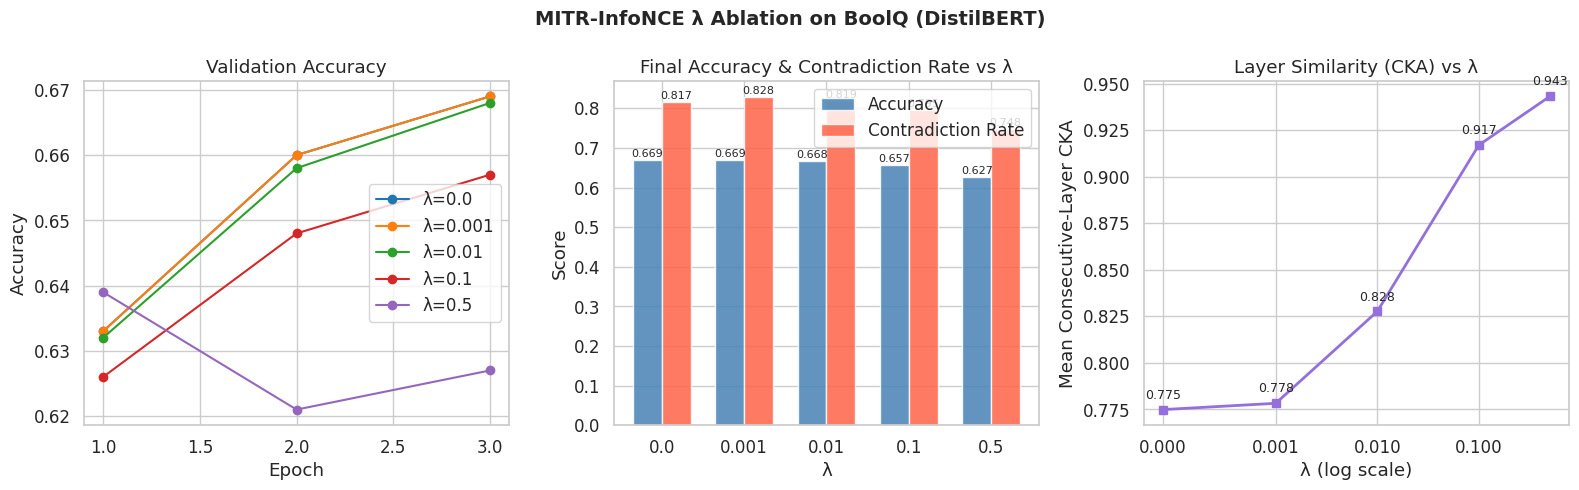

Figure saved as lambda_ablation_results.png


In [9]:
sns.set_theme(style='whitegrid', font_scale=1.1)
colors = sns.color_palette('tab10', len(LAMBDAS))
epochs = list(range(1, EPOCHS + 1))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('MITR-InfoNCE λ Ablation on BoolQ (DistilBERT)', fontsize=14, fontweight='bold')

# ── Plot 1: Validation Accuracy per epoch ─────────────────────────────────
ax = axes[0]
for i, r in enumerate(all_results):
    ax.plot(epochs, r['acc_curve'], marker='o', color=colors[i], label=f'λ={r["lam"]}')
ax.set_title('Validation Accuracy')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.legend()

# ── Plot 2: Final Accuracy & Contradiction Rate vs λ (summary bar) ────────
ax = axes[1]
lam_labels = [str(r['lam']) for r in all_results]
final_accs    = [r['final_acc']   for r in all_results]
final_contras = [r['final_contra'] for r in all_results]

x = np.arange(len(lam_labels))
width = 0.35
b1 = ax.bar(x - width/2, final_accs,    width, label='Accuracy',        color='steelblue',  alpha=0.85)
b2 = ax.bar(x + width/2, final_contras, width, label='Contradiction Rate', color='tomato', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(lam_labels)
ax.set_xlabel('λ')
ax.set_ylabel('Score')
ax.set_title('Final Accuracy & Contradiction Rate vs λ')
ax.legend()

# annotate
for bar in b1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in b2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

# ── Plot 3: Mean CKA similarity vs λ (summary) ────────────────────────────
ax = axes[2]
final_ckas = [r['final_cka'] for r in all_results]
ax.plot(LAMBDAS, final_ckas, marker='s', color='mediumpurple', linewidth=2)
for lv, cv in zip(LAMBDAS, final_ckas):
    ax.annotate(f'{cv:.3f}', (lv, cv), textcoords='offset points',
                xytext=(0, 8), ha='center', fontsize=9)
ax.set_xscale('symlog', linthresh=0.001)
ax.set_xlabel('λ (log scale)')
ax.set_ylabel('Mean Consecutive-Layer CKA')
ax.set_title('Layer Similarity (CKA) vs λ')
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())

plt.tight_layout()
plt.savefig('lambda_ablation_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved as lambda_ablation_results.png')